# N-Body Neural Networks Testing

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import time
import os
from google.colab import drive
from math import atan2, sqrt, sin, cos, pi

In [ ]:
G_REAL = 6.6743e-11
G = 1

MU = 1e30
AU = 149597870700 # ​≈ 1.5e11

TU = sqrt(AU**3 / (G_REAL * MU)) # ​≈ 7 082 478 seconds ≈ 82 days
TU_AU = TU / AU

dt = 0.001
epsilon = 0.05

METHODS = {
    0: "Kepler 2-Body",
    1: "Semi-Implicit Euler",
    2: "Velocity Verlet",
    3: "Runge-Kutta 4"
}

MODELS = {
    1: "MLP",
    2: "LSTM",
    3: "GNN",
    4: "GNODE",
    5: "PI-GNN"
}

MODEL_PATHS = {
    1: '/content/drive/MyDrive/Colab Notebooks/model_MLP_nbody.keras',
    2: '/content/drive/MyDrive/Colab Notebooks/model_LSTM_nbody.keras',
    3: '/content/drive/MyDrive/Colab Notebooks/model_GNN_nbody.keras',
    4: '/content/drive/MyDrive/Colab Notebooks/model_GNODE_nbody.keras',
    5: '/content/drive/MyDrive/Colab Notebooks/model_PIGNN_nbody.keras',
}

## Physics Engine

### Classes

In [ ]:
class Body:
  def __init__(self, mass, position, velocity):
    self.mass = float(mass)
    self.position = np.array(position, dtype=float)
    self.velocity = np.array(velocity, dtype=float)
    self.acceleration = np.zeros(2, dtype=float)

  def __repr__(self):
    pos_str = np.array2string(self.position, formatter={'float_kind':lambda x: f"{x:.6f}"})
    vel_str = np.array2string(self.velocity, formatter={'float_kind':lambda x: f"{x:.6f}"})
    acc_str = np.array2string(self.acceleration, formatter={'float_kind':lambda x: f"{x:.6f}"})

    return (
        f"mass: {self.mass:.6f}, "
        f"pos: {pos_str}, "
        f"vel: {vel_str}, "
        f"acc: {acc_str}"
    )

In [ ]:
class KeplerBody(Body):
  def __init__(self, mass, position, velocity):
    super().__init__(mass, position, velocity)
    self.mu = 0
    self.a = 0
    self.e = 0
    self.n = 0
    self.M0 = 0
    self.arg_perigee = 0

  def init_orbit(self, central_body):
    r_vec = self.position - central_body.position
    v_vec = self.velocity - central_body.velocity

    r_mag = np.linalg.norm(r_vec)
    v_mag_sq = np.dot(v_vec, v_vec)

    self.mu = central_body.mass + self.mass
    self.a = 1.0 / ((2.0 / r_mag) - (v_mag_sq / self.mu))

    rdotv = np.dot(r_vec, v_vec)

    v2_mur = v_mag_sq - self.mu / r_mag

    e_vec = (v2_mur * r_vec - rdotv * v_vec) / self.mu
    self.e = np.linalg.norm(e_vec)

    self.arg_perigee = atan2(e_vec[1], e_vec[0])
    self.n = sqrt(self.mu / (self.a ** 3))

    cos_nu = np.clip(np.dot(e_vec, r_vec) / (self.e * r_mag), -1.0, 1.0)

    nu0 = np.arccos(cos_nu)
    if rdotv < 0:
        nu0 = 2 * pi - nu0

    E0 = 2 * atan2(
        sqrt(1 - self.e**2) * sin(nu0),
        1 - self.e * cos(nu0)
    )

    self.M0 = E0 - self.e * sin(E0)

  def step_kepler(self, t, central_body):
    M = (self.M0 + self.n * t) % (2 * pi)

    E_val = M
    delta = 1

    for _ in range(50):
      f = E_val - self.e * sin(E_val) - M
      f_prime = 1 - self.e * cos(E_val)

      delta = f / f_prime
      E_val -= delta

      if abs(delta) < 1e-12: break

    x_p = self.a * (cos(E_val) - self.e)
    y_p = self.a * sqrt(1 - self.e**2) * sin(E_val)

    r_inst = self.a * (1 - self.e * cos(E_val))
    v_factor = sqrt(self.mu * self.a) / r_inst

    vx_p = -v_factor * sin(E_val)
    vy_p = v_factor * sqrt(1 - self.e**2) * cos(E_val)

    cos_ap = cos(self.arg_perigee)
    sin_ap = sin(self.arg_perigee)

    x_rel = x_p * cos_ap - y_p * sin_ap
    y_rel = x_p * sin_ap + y_p * cos_ap

    vx_rel = vx_p * cos_ap - vy_p * sin_ap
    vy_rel = vx_p * sin_ap + vy_p * cos_ap

    Mtot = self.mass + central_body.mass

    self.position = np.array([
        -(central_body.mass / Mtot) * x_rel,
        -(central_body.mass / Mtot) * y_rel
    ])

    central_body.position = np.array([
        (self.mass / Mtot) * x_rel,
        (self.mass / Mtot) * y_rel
    ])

    self.velocity = np.array([
        -(central_body.mass / Mtot) * vx_rel,
        -(central_body.mass / Mtot) * vy_rel
    ])

    central_body.velocity = np.array([
        (self.mass / Mtot) * vx_rel,
        (self.mass / Mtot) * vy_rel
    ])

In [ ]:
class EulerBody(Body):
  def update_accelerations(self, others):
    accelerations = np.zeros(2, dtype=float)

    for other in others:
      if other is self: continue

      r_vec = other.position - self.position
      r_mag = np.linalg.norm(r_vec)

      accelerations += other.mass * r_vec / (r_mag**2 + epsilon**2)**1.5

    self.acceleration[:] = accelerations

  def update_velocity_positions(self, dt):
    # Semi-Implicit Euler (Euler-Cromer) Method
    self.velocity += self.acceleration * dt
    self.position += self.velocity * dt

In [ ]:
class VerletBody(Body):
  def __init__(self, mass, position, velocity):
    super().__init__(mass, position, velocity)
    self.old_acceleration = np.zeros(2, dtype=float)

  def update_acceleration(self, others):
    # store old acceleration
    self.old_acceleration = self.acceleration.copy()
    acc = np.zeros(2, dtype=float)
    for other in others:
      if other is self: continue
      r_vec = other.position - self.position
      r_sq_eps = np.dot(r_vec, r_vec) + epsilon**2
      acc += other.mass * r_vec / (r_sq_eps ** 1.5)
    self.acceleration = acc

  def update_velocity(self, dt):
    self.velocity += 0.5 * (self.old_acceleration + self.acceleration) * dt

  def update_position(self, dt):
    self.position += (self.velocity * dt + 0.5 * self.acceleration * dt**2)

In [ ]:
class RK4Body(Body):
  def __init__(self, mass, position, velocity):
    super().__init__(mass, position, velocity)
    # k vectors (velocity + acceleration samples)
    self.kv = [np.zeros(2) for _ in range(4)]
    self.ka = [np.zeros(2) for _ in range(4)]
    # temporary states
    self.temp_pos = np.zeros(2)
    self.temp_vel = np.zeros(2)

  def get_acceleration(self, others):
    acc = np.zeros(2)
    for other in others:
      if other is self: continue
      r_vec = other.temp_pos - self.temp_pos
      r2_epsilon = np.dot(r_vec, r_vec) + epsilon**2
      acc += other.mass * r_vec / (r2_epsilon ** 1.5)
    return acc

### Functions

In [ ]:
def run_kepler(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  body1 = bodies[0]
  body2 = bodies[1]

  x.clear()
  y.clear()

  x.extend([[], []])
  y.extend([[], []])

  body1.init_orbit(body2)
  current_time = 0

  for _ in range(steps):

    # UPDATE PARAMETERS
    current_time += dt
    body1.step_kepler(current_time, body2)


    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 0, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    x[0].append(body1.position[0])
    y[0].append(body1.position[1])

    x[1].append(body2.position[0])
    y[1].append(body2.position[1])

In [ ]:
def run_euler(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  for _ in range(steps):

    # UPDATE PARAMETERS
    # Update accelerations
    for body in bodies:
      body.update_accelerations(bodies)

    # Update velocity and positions
    for body in bodies:
      body.update_velocity_positions(dt)


    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 1, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    for i, body in enumerate(bodies):
      x[i].append(body.position[0])
      y[i].append(body.position[1])

In [ ]:
def run_verlet(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  for _ in range(steps):

    # UPDATE PARAMETERS
    # Update positions
    for body in bodies:
      body.update_position(dt)

    # Update accelerations
    for body in bodies:
      body.update_acceleration(bodies)

    # Update velocities
    for body in bodies:
      body.update_velocity(dt)


    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 2, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    for i, body in enumerate(bodies):
      x[i].append(body.position[0])
      y[i].append(body.position[1])

In [ ]:
def run_rk4(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  for _ in range(steps):
    # UPDATE PARAMETERS

    # Step k1
    # Assign values to temporary variables
    for b in bodies:
        b.temp_pos = b.position.copy()

    # kv1 and ka1 are the current velocity and acceleration values
    for b in bodies:
        b.kv[0] = b.velocity.copy()
        b.ka[0] = b.get_acceleration(bodies)

    # Step k2
    # Calculate the temporary positions and velocities at half-step
    for b in bodies:
        b.temp_pos = b.position + b.kv[0] * dt * 0.5
        b.temp_vel = b.velocity + b.ka[0] * dt * 0.5

    # Recalculate the accelerations given the updated positions
    for b in bodies:
        b.kv[1] = b.temp_vel.copy()
        b.ka[1] = b.get_acceleration(bodies)

    # Step k3
    # Recalculate the temporary positions and velocities at half-step using past slope (velocity and acceleration)
    for b in bodies:
        b.temp_pos = b.position + b.kv[1] * dt * 0.5
        b.temp_vel = b.velocity + b.ka[1] * dt * 0.5

    for b in bodies:
        b.kv[2] = b.temp_vel.copy()
        b.ka[2] = b.get_acceleration(bodies)

    # Step k4
    # Calculate the "draft" of the final positions and velocities
    for b in bodies:
        b.temp_pos = b.position + b.kv[2] * dt
        b.temp_vel = b.velocity + b.ka[2] * dt

    for b in bodies:
        b.kv[3] = b.temp_vel.copy()
        b.ka[3] = b.get_acceleration(bodies)

    # Final Integration
    for b in bodies:
        b.position += (dt / 6.0) * (b.kv[0] + 2*b.kv[1] + 2*b.kv[2] + b.kv[3])
        b.velocity += (dt / 6.0) * (b.ka[0] + 2*b.ka[1] + 2*b.ka[2] + b.ka[3])

    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 3, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    for i, body in enumerate(bodies):
      x[i].append(body.position[0])
      y[i].append(body.position[1])

In [ ]:
methods_functions = {
    0: run_kepler,
    1: run_euler,
    2: run_verlet,
    3: run_rk4
}

## Model Loader

In [ ]:
def load_model(option):
  PATH = MODEL_PATHS[option]
  if option in [1, 2]:
    model = tf.keras.models.load_model(PATH)

    print("Success! Model uploaded successfully!")
    model.summary()
    return model

  elif option == 3:
    HIDDEN_LAYER_SIZE = 128
    class GNN(tf.keras.layers.Layer):
      def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.node = tf.keras.Sequential([
            tf.keras.layers.Dense(dim, activation='swish'),
            tf.keras.layers.Dense(4)
            ])
        self.edge = tf.keras.Sequential([
            tf.keras.layers.Dense(dim, activation='swish'),
            tf.keras.layers.Dense(dim, activation='swish')
            ])

      def call(self, nodes):
        current_dtype = nodes.dtype
        num_bodies = tf.shape(nodes)[1]

        receiver_states = tf.expand_dims(nodes, axis=2)
        receiver_states = tf.repeat(receiver_states, num_bodies, axis=2)

        sender_states = tf.expand_dims(nodes, axis=1)
        sender_states = tf.repeat(sender_states, num_bodies, axis=1)

        interaction_input = tf.concat([receiver_states, sender_states], axis=-1)
        pairwise_messages = self.edge(interaction_input)

        mask = tf.eye(num_bodies, dtype=current_dtype)
        mask = tf.reshape(mask, (1, num_bodies, num_bodies, 1))

        pairwise_messages = pairwise_messages * (tf.cast(1.0, current_dtype) - mask)
        total_messages = tf.reduce_sum(pairwise_messages, axis=2)

        return self.node(total_messages)

    inputs = tf.keras.Input(shape=(None, 5))
    outputs = GNN(dim=256)(inputs)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    dummy_input = tf.zeros((1, 5, 5), dtype='float32')
    _ = model(dummy_input)

    print("Injecting weights into initialized architecture...")
    model.load_weights(PATH)

    print("Success! Universal model architecture and weights matched completely!")
    model.summary()
    return model

  elif option == 4:
    HIDDEN_LAYER_SIZE = 128
    class Encoder(tf.keras.layers.Layer):
      def __init__(self, hidden_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.dense = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.out = tf.keras.layers.Dense(output_dim)
        self.norm = tf.keras.layers.LayerNormalization()

      def call(self, x):
        x = self.dense(x)
        x = self.out(x)
        return self.norm(x)

      def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], self.output_dim)

    class GNN(tf.keras.layers.Layer):
      def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.node = tf.keras.Sequential([
            tf.keras.layers.Dense(dim, activation='swish'),
            tf.keras.layers.Dense(2)
        ])
        self.edge = tf.keras.Sequential([
            tf.keras.layers.Dense(dim, activation='swish'),
            tf.keras.layers.Dense(dim, activation='swish')
        ])

      def call(self, nodes):
        current_dtype = nodes.dtype

        num_bodies = tf.shape(nodes)[1]

        receiver_states = tf.expand_dims(nodes, axis=2)
        receiver_states = tf.repeat(receiver_states, num_bodies, axis=2)

        sender_states = tf.expand_dims(nodes, axis=1)
        sender_states = tf.repeat(sender_states, num_bodies, axis=1)

        interaction_input = tf.concat([receiver_states, sender_states], axis=-1)
        pairwise_messages = self.edge(interaction_input)

        mask = tf.eye(num_bodies, dtype=current_dtype)
        mask = tf.reshape(mask, (1, num_bodies, num_bodies, 1))

        pairwise_messages = pairwise_messages * (tf.cast(1.0, current_dtype) - mask)
        total_messages = tf.reduce_sum(pairwise_messages, axis=2)

        return self.node(total_messages)

      def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], 2)

    class ODE(tf.keras.layers.Layer):
      def __init__(self, dt, **kwargs):
        super().__init__(**kwargs)
        self.dt = dt

      def call(self, current_state, accelerations):
        pos = current_state[:, :, 1:3]
        vel = current_state[:, :, 3:5]
        dt = self.dt

        # Velocity Verlet
        new_pos = pos + vel * dt + 0.5 * accelerations * (dt**2)
        new_vel = vel + accelerations * dt

        return tf.concat([new_pos, new_vel], axis=-1)

      def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], 4)

    inputs = tf.keras.Input(shape=(None, 5))
    encoder = Encoder(hidden_dim=HIDDEN_LAYER_SIZE, output_dim=HIDDEN_LAYER_SIZE)
    gnn = GNN(dim=HIDDEN_LAYER_SIZE)
    ode = ODE(dt=dt)

    latent_values = encoder(inputs)
    accelerations = gnn(latent_values)
    outputs = ode(inputs, accelerations)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    dummy_input = tf.zeros((1, 5, 5), dtype='float32')
    _ = model(dummy_input)

    print("Injecting weights into initialized architecture...")
    model.load_weights(PATH)

    print("Success! Universal model architecture and weights matched completely!")
    model.summary()
    return model

  elif option == 5:
    HIDDEN_LAYER_SIZE = 128
    class GNN(tf.keras.layers.Layer):
        def __init__(self, dim, **kwargs):
          super().__init__(**kwargs)
          self.node = tf.keras.Sequential([
              tf.keras.layers.Dense(dim, activation='swish'),
              tf.keras.layers.Dense(2) # Output: ax, ay
          ])
          self.edge = tf.keras.Sequential([
              tf.keras.layers.Dense(dim, activation='swish'),
              tf.keras.layers.Dense(dim, activation='swish')
          ])

        def call(self, nodes):
          current_dtype = nodes.dtype
          N_nodes = tf.shape(nodes)[1]

          receiver_states = tf.expand_dims(nodes, axis=2)
          receiver_states = tf.repeat(receiver_states, N_nodes, axis=2)

          sender_states = tf.expand_dims(nodes, axis=1)
          sender_states = tf.repeat(sender_states, N_nodes, axis=1)

          interaction_input = tf.concat([receiver_states, sender_states], axis=-1)
          pairwise_messages = self.edge(interaction_input)

          mask = tf.eye(N_nodes, dtype=current_dtype)
          mask = tf.reshape(mask, (1, N_nodes, N_nodes, 1))

          pairwise_messages = pairwise_messages * (tf.cast(1.0, current_dtype) - mask)
          total_messages = tf.reduce_sum(pairwise_messages, axis=2)

          return self.node(total_messages)

    inputs = tf.keras.Input(shape=(N, 5))
    outputs = GNN(dim=HIDDEN_LAYER_SIZE)(inputs)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    print("Injecting weights into initialized architecture...")
    model.load_weights(PATH)

    print("Success! Universal model architecture and weights matched completely!")
    model.summary()
    return model

  else: print("Option model not valid!")

### Functions

In [ ]:
def run_mlp(initial_state, model, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  ai_path = []
  temp_input = initial_state

  mass_indices = [i * 5 for i in range(N)]
  masses = initial_state[0, mass_indices]

  print(f"Running generalized {MODELS.get(1)} trajectory simulation for {N} bodies...")

  for _ in range(steps):
    prediction = model.predict(temp_input, verbose=0)
    ai_path.append(prediction[0])

    next_input = np.zeros((1, 5 * N), dtype='float32')
    for i in range(N):
      next_input[0, i*5] = masses[i]
      next_input[0, i*5+1:5*(i+1)] = prediction[0, i*4:4*(i+1)]

    # For calculating the invariants
    temp_predicted_bodies = []
    for i in range(N):
      temp_predicted_bodies.append(RK4Body(
          mass=masses[i],
          position=prediction[0, i*4 : i*4+2],
          velocity=prediction[0, i*4+2 : i*4+4]))

    calculate_validation_step(temp_predicted_bodies, 0, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)
    temp_input = next_input

  ai_path = np.array(ai_path)
  for i in range(N):
    start_idx = i * 4
    x.append(ai_path[:, start_idx])
    y.append(ai_path[:, start_idx + 1])

In [ ]:
def run_lstm(initial_state, model, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  ai_path = []
  memory_buffer = np.tile(initial_state, (1, 10, 1))
  temp_input = memory_buffer

  mass_indices = [i * 5 for i in range(N)]
  masses = initial_state[0, mass_indices]

  print(f"Running generalized {MODELS.get(2)} trajectory simulation for {N} bodies...")

  for _ in range(steps):
    prediction = model.predict(temp_input, verbose=0)
    ai_path.append(prediction[0])

    next_frame = np.zeros((1, 5 * N), dtype='float32')
    for i in range(N):
      next_frame[0, i*5] = masses[i]
      next_frame[0, i*5+1 : 5*(i+1)] = prediction[0, i*4 : 4*(i+1)]

    # For calculating the invariants
    temp_predicted_bodies = []
    for i in range(N):
      temp_predicted_bodies.append(RK4Body(
          mass=masses[i],
          position=prediction[0, i*4 : i*4+2],
          velocity=prediction[0, i*4+2 : i*4+4]))

    calculate_validation_step(temp_predicted_bodies, 0, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)
    next_frame_3d = np.expand_dims(next_frame, axis=1)
    temp_input = np.concatenate([temp_input[:, 1:, :], next_frame_3d], axis=1)

  ai_path = np.array(ai_path)

  for i in range(N):
    start_idx = i * 4
    x.append(ai_path[:, start_idx])
    y.append(ai_path[:, start_idx + 1])

In [ ]:
def run_gnn_gnode(initial_state, model, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  ai_path = []
  temp_input = initial_state

  print(f"Running generalized GNN/GNODE trajectory simulation for {N} bodies...")

  for _ in range(steps):
    prediction = model.predict(temp_input, verbose=0)
    ai_path.append(prediction[0])

    # For invariants
    temp_predicted_bodies = []
    for i in range(N):
      temp_predicted_bodies.append(RK4Body(
          mass=temp_input[0, i, 0],
          position=prediction[0, i, 0:2],
          velocity=prediction[0, i, 2:4]))

    calculate_validation_step(temp_predicted_bodies, 0, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)
    temp_input = np.concatenate([temp_input[:, :, 0:1], prediction], axis=-1)

  ai_path = np.array(ai_path)
  for i in range(N):
    x.append(ai_path[:, i, 0])
    y.append(ai_path[:, i, 1])

In [ ]:
def run_pignn(initial_state, model, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  ai_path = []
  temp_input = np.copy(initial_state) # Shape: (1, N, 5)

  print(f"Running generalized {MODELS.get(5)} trajectory simulation for {N} bodies...")

  for _ in range(steps):
    masses = temp_input[:, :, 0:1]     # Shape: (1, N, 1)
    pos_t  = temp_input[:, :, 1:3]     # Shape: (1, N, 2)
    vel_t  = temp_input[:, :, 3:5]     # Shape: (1, N, 2)

    pred_acc = model(tf.convert_to_tensor(temp_input), training=False).numpy()
    vel_next = vel_t + (pred_acc * dt)
    pos_next = pos_t + (vel_next * dt)

    step_decoded = np.concatenate([pos_next, vel_next], axis=-1)[0]
    ai_path.append(step_decoded)

    # For invariants
    temp_predicted_bodies = []
    for i in range(N):
      temp_predicted_bodies.append(RK4Body(
        mass=masses[0, i, 0],
        position=pos_next[0, i],
        velocity=vel_next[0, i]))

    calculate_validation_step(temp_predicted_bodies, 0, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)
    temp_input = np.concatenate([masses, pos_next, vel_next], axis=-1)

  ai_path = np.array(ai_path)
  for i in range(N):
    x.append(ai_path[:, i, 0])
    y.append(ai_path[:, i, 1])

In [ ]:
models_functions = {
    1: run_mlp,
    2: run_lstm,
    3: run_gnn_gnode,
    4: run_gnn_gnode,
    5: run_pignn
}

## Helper Functions

### Physical Invariants

In [ ]:
# Kinetic Energy
def KE(m, v): return 0.5 * m * np.dot(v, v)

# Potential Energy
def PE(m1, m2, r1, r2, option):
  r_vec = r1 - r2
  r2_val = np.dot(r_vec, r_vec)

  if option == 0:
    r = np.sqrt(r2_val)
    return -m1 * m2 / r
  else:
    return -m1 * m2 / np.sqrt(r2_val + epsilon**2)

# Linear Momentum
def P(m, v): return m * np.array(v)

# Angular Momentum
def L(m, r, v): return m * (r[0] * v[1] - r[1] * v[0])

# Total Energy
def energy(bodies, option):
  ke = 0.0
  pe = 0.0

  for i, body in enumerate(bodies):
    ke += KE(body.mass, body.velocity)
    for j in range(i + 1, len(bodies)):
      pe += PE(body.mass, bodies[j].mass, body.position, bodies[j].position, option)
  return ke + pe

# Total Linear Momentum
def linear_momentum(bodies):
  current_p = np.array([0.0, 0.0])
  for body in bodies: current_p += P(body.mass, body.velocity)
  return current_p

# Total Angular Momentum
def angular_momentum(bodies):
  current_l = 0
  for body in bodies: current_l += L(body.mass, body.position, body.velocity)
  return current_l

# Calculate all validation quantities
def calculate_validation_step(bodies, option, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
    nom_E = abs(E0) if abs(E0) > 1e-15 else 1.0
    nom_P = np.linalg.norm(P0) if np.linalg.norm(P0) > 1e-15 else 1.0
    nom_L = abs(L0) if abs(L0) > 1e-15 else 1.0

    E_current = energy(bodies, option)
    P_current = linear_momentum(bodies)
    L_current = angular_momentum(bodies)

    err_e_abs = abs(E_current - E0)
    err_p_abs = np.linalg.norm(P_current - P0)
    err_l_abs = abs(L_current - L0)

    e.append(E_current)
    p.append(np.linalg.norm(P_current))
    l.append(L_current)

    abs_e.append(err_e_abs)
    abs_p.append(err_p_abs)
    abs_l.append(err_l_abs)

    rel_e.append((err_e_abs / nom_E) * 100)
    rel_p.append((err_p_abs / nom_P) * 100)
    rel_l.append((err_l_abs / nom_L) * 100)

### Initial Configuration

In [ ]:
def generate_bodies(option):
  bodies = []

  sum_vx = 0.0
  sum_vy = 0.0

  for i in range(N):
    mass = rd.uniform(0.5, 2)

    x_pos = rd.uniform(-1, 1)
    y_pos = rd.uniform(-1, 1)

    if i < N - 1:
      vx = rd.uniform(-2e4, 2e4) * TU_AU
      vy = rd.uniform(-2e4, 2e4) * TU_AU

      sum_vx += mass * vx
      sum_vy += mass * vy

    else:
      vx = -sum_vx / mass
      vy = -sum_vy / mass

    pos = np.array([x_pos, y_pos], dtype=float)
    vel = np.array([vx, vy], dtype=float)

    if option == 0: body = KeplerBody(mass, pos, vel)
    elif option == 1: body = EulerBody(mass, pos, vel)
    elif option == 2: body = VerletBody(mass, pos, vel)
    elif option == 3: body = RK4Body(mass, pos, vel)

    bodies.append(body)
    print(f"Body {i+1}: {body}")

  return bodies

In [ ]:
# Predefined configuratoins
BODIES_3 = [
    RK4Body(mass=1.0, position=[0.0, 1.0], velocity=[-0.5, 0.0]),
    RK4Body(mass=1.0, position=[-0.866, -0.5], velocity=[0.25, 0.433]),
    RK4Body(mass=1.0, position=[0.866, -0.5], velocity=[0.25, -0.433])
]

BODIES_4 = [
    RK4Body(mass=1.0, position=[0.0, 1.0], velocity=[-0.5, 0.1]),
    RK4Body(mass=1.0, position=[-0.866, -0.5], velocity=[0.25, 0.433]),
    RK4Body(mass=1.0, position=[0.866, -0.5], velocity=[0.25, -0.433]),
    RK4Body(mass=1.5, position=[0.0, 0.0], velocity=[0.0, 0.15])
]

BODIES_5 = [
    RK4Body(mass=1.00, position=[0.0, 0.0], velocity=[0.35, 0.45]),
    RK4Body(mass=0.98, position=[-1.2, 0.5], velocity=[-0.2, -0.6]),
    RK4Body(mass=1.02, position=[1.2, -0.5], velocity=[-0.2, 0.6]),
    RK4Body(mass=1.0, position=[0.5, 1.2], velocity=[-0.6, -0.1]),
    RK4Body(mass=1.0, position=[-0.5, -1.2], velocity=[0.6, -0.1])
]

BODIES_10 = [
    RK4Body(mass=1.007, position=[0.8312, 0.0000], velocity=[-0.0028, 1.2012]),
    RK4Body(mass=0.985, position=[0.2624, 0.9031], velocity=[-1.0342, 0.3661]),
    RK4Body(mass=1.011, position=[-0.7681, 0.4993], velocity=[-0.6412, -0.9832]),
    RK4Body(mass=0.994, position=[-0.6872, -0.5584], velocity=[0.7082, -0.8712]),
    RK4Body(mass=1.002, position=[0.2934, -0.8081], velocity=[1.1492, 0.3341]),
    RK4Body(mass=0.999, position=[1.7142, 0.0000], velocity=[-0.0032, -0.7651]),
    RK4Body(mass=1.001, position=[0.5251, 1.8073], velocity=[0.7241, -0.2034]),
    RK4Body(mass=1.016, position=[-1.5361, 0.9982], velocity=[0.3972, 0.6221]),
    RK4Body(mass=0.984, position=[-1.3762, -1.1163], velocity=[-0.4521, 0.5412]),
    RK4Body(mass=1.001, position=[0.5873, -1.6112], velocity=[-0.6491, -0.2361])
]

In [ ]:
def get_initial_state(option, bodies):
  if option in [1, 2]:
    initial_list = []
    for body in bodies:
      initial_list.append(body.mass)
      initial_list.append(body.position[0])
      initial_list.append(body.position[1])
      initial_list.append(body.velocity[0])
      initial_list.append(body.velocity[1])
    initial_state = np.array(initial_list, dtype='float32').reshape(1, 15)

  elif option in [3, 4, 5]:
    initial_list = []
    for body in bodies:
      initial_list.append([body.mass,
        body.position[0], body.position[1],
        body.velocity[0], body.velocity[1]])
    initial_state = np.array(initial_list, dtype='float32').reshape(1, N, 5)

  else:
    print("Option model invalid!")
    return

  return initial_state

### Evaluation

In [ ]:
def evaluate_trajectories(intervals, x_real, y_real, x_ai, y_ai, hist_mae, hist_mse):
  predicted_trajectory = np.stack([np.array(x_ai).T, np.array(y_ai).T], axis=-1) #[1:]
  real_trajectory = np.stack([np.array(x_real).T, np.array(y_real).T], axis=-1)[1:]
  available_steps = predicted_trajectory.shape[0]

  abs_errors = np.abs(predicted_trajectory - real_trajectory)
  sq_errors = np.square(predicted_trajectory - real_trajectory)

  for bin_label, (start, end) in intervals.items():
    actual_end = min(end, available_steps)

    bin_abs = abs_errors[start:actual_end]
    bin_sq  = sq_errors[start:actual_end]

    bin_mae = np.mean(bin_abs)
    bin_mse = np.mean(bin_sq)

    hist_mae[bin_label].append(bin_mae)
    hist_mse[bin_label].append(bin_mse)


def evaluate_conserved_quantities(abs_e, abs_p, abs_l,
                                  hist_e_mae, hist_p_mae, hist_l_mae,
                                  hist_e_max, hist_p_max, hist_l_max):
  energy_mae  = np.mean(abs_e)
  linear_mae  = np.mean(abs_p)
  angular_mae = np.mean(abs_l)

  energy_max  = np.max(abs_e)
  linear_max  = np.max(abs_p)
  angular_max = np.max(abs_l)

  hist_e_mae.append(energy_mae)
  hist_p_mae.append(linear_mae)
  hist_l_mae.append(angular_mae)

  hist_e_max.append(energy_max)
  hist_p_max.append(linear_max)
  hist_l_max.append(angular_max)


def evaluate_runtime(hist_runtime, time):
  hist_runtime.append(time)

In [ ]:
def print_evaluation_trajectories(option, intervals, hist_mae, hist_mse):
  headers = list(intervals.keys())
  num_runs = len(hist_mae[headers[0]])

  print(f"Mean Absolute Error (MAE) per run for {MODELS.get(option)}:")
  print(f"{'':<8}   " + "   ".join(f"{h:^16}" for h in headers))
  for i in range(num_runs):
    row_cells = []
    for h in headers:
      if i < len(hist_mae[h]):
        val = hist_mae[h][i]
        row_cells.append(f"{val:^16.10f}")
      else:
        row_cells.append(f"{'---':^16}")
    print(f"Run {i+1:<4}   " + "   ".join(row_cells))

  print(f"\nMean Squared Error (MSE) per run for {MODELS.get(option)}:")
  print(f"{'':<8}   " + "   ".join(f"{h:^16}" for h in headers))
  for i in range(num_runs):
    row_cells = []
    for h in headers:
      if i < len(hist_mse[h]):
        val = hist_mse[h][i]
        row_cells.append(f"{val:^16.10f}")
      else:
        row_cells.append(f"{'---':^16}")
    print(f"Run {i+1:<4}   " + "   ".join(row_cells))

  for bin_label in intervals.keys():
    if not hist_mae[bin_label]:
      print(f"Interval {bin_label:<10}   Skipped entirely.")
      continue

    avg_mae = np.mean(hist_mae[bin_label])
    avg_mse = np.mean(hist_mse[bin_label])
    std_mae = np.std(hist_mae[bin_label])

    print(f"Interval {bin_label:<10}   Avg MAE: {avg_mae:.10f} (±{std_mae:.5f})   Avg MSE: {avg_mse:.10e}")

In [ ]:
def print_evaluation_conserved_quantities(option,
                                          hist_e_mae, hist_e_max,
                                          hist_p_mae, hist_p_max,
                                          hist_l_mae, hist_l_max):
  headers = ["Energy", "Linear Mom.", "Angular Mom."]
  num_runs = len(hist_e_mae)

  print(f"Mean Absolute Error (MAE) per run for {MODELS.get(option)}:")
  print(f"{'':<10} {headers[0]:^14} {headers[1]:^14} {headers[2]:^14}")
  for i in range(num_runs):
    print(f"Run {i+1:<6} "
          f"{hist_e_mae[i]:^14.4e} "
          f"{hist_p_mae[i]:^14.4e} "
          f"{hist_l_mae[i]:^14.4e}")

  print(f"\nMaximum Absolute Error (Max Error) per run for {MODELS.get(option)}:")
  print(f"{'':<10} {headers[0]:^14} {headers[1]:^14} {headers[2]:^14}")
  for i in range(num_runs):
    print(f"Run {i+1:<6} "
          f"{hist_e_max[i]:^14.4e} "
          f"{hist_p_max[i]:^14.4e} "
          f"{hist_l_max[i]:^14.4e}")

  final_mean_energy_mae = np.mean(hist_e_mae)
  final_std_energy_mae  = np.std(hist_e_mae)

  final_mean_energy_max = np.mean(hist_e_max)
  final_std_energy_max  = np.std(hist_e_max)

  final_mean_linear_mae = np.mean(hist_p_mae)
  final_std_linear_mae  = np.std(hist_p_mae)

  final_mean_linear_max = np.mean(hist_p_max)
  final_std_linear_max  = np.std(hist_p_max)

  final_mean_angular_mae = np.mean(hist_l_mae)
  final_std_angular_mae  = np.std(hist_l_mae)

  final_mean_angular_max = np.mean(hist_l_max)
  final_std_angular_max  = np.std(hist_l_max)

  print(f"\nValidation metrics for {MODELS.get(option)}:")
  print(f"Energy MAE:                 {final_mean_energy_mae:.3e} ± {final_std_energy_mae:.3e}")
  print(f"Energy Max Error:           {final_mean_energy_max:.3e} ± {final_std_energy_max:.3e}")
  print(f"Linear Momentum MAE:        {final_mean_linear_mae:.3e} ± {final_std_linear_mae:.3e}")
  print(f"Linear Momentum Max Error:  {final_mean_linear_max:.3e} ± {final_std_linear_max:.3e}")
  print(f"Angular Momentum MAE:       {final_mean_angular_mae:.3e} ± {final_std_angular_mae:.3e}")
  print(f"Angular Momentum Max Error: {final_mean_angular_max:.3e} ± {final_std_angular_max:.3e}")

In [ ]:
def print_evaluation_runtime(option, hist_runtime):
  num_runs = len(hist_runtime)

  print(f"Runtime Execution for {MODELS.get(option)}:")
  print(f"{'':<10} {'Runtime':^14}")
  for i in range(num_runs):
    print(f"Run {i+1:<6} "
          f"{hist_runtime[i]:^14.4e}")

  mean_runtime = np.mean(hist_runtime)
  std_runtime = np.std(hist_runtime)

  print(f"Mean Runtime: {mean_runtime:.4e}s ± {std_runtime:.4e}s")

### Plotting

In [ ]:
def plot_trajectory_comparison(N, x_real, y_real, x_ai, y_ai):
  fig, ax = plt.subplots(figsize=(6, 6))
  ax.set_aspect('equal')

  all_x = np.concatenate([np.array(x).flatten() for x in x_ai + x_real])
  all_y = np.concatenate([np.array(y).flatten() for y in y_ai + y_real])

  finite_x = all_x[np.isfinite(all_x)]
  finite_y = all_y[np.isfinite(all_y)]

  if len(finite_x) == 0 or len(finite_y) == 0:
    x_min, x_max = -1.0, 1.0
    y_min, y_max = -1.0, 1.0
  else:
    x_min, x_max = np.min(finite_x), np.max(finite_x)
    y_min, y_max = np.min(finite_y), np.max(finite_y)

  margin_x = (x_max - x_min) * 0.1
  margin_y = (y_max - y_min) * 0.1

  ax.set_xlim(x_min - margin_x, x_max + margin_x)
  ax.set_ylim(y_min - margin_y, y_max + margin_y)

  cmap = plt.get_cmap('tab10')

  for i in range(N):
    color = cmap(i % 10)

    ax.plot(x_real[i], y_real[i], color=color, linestyle='--', alpha=0.4, label=f'Body {i+1} (Ground Truth)')
    ax.plot(x_ai[i], y_ai[i], color=color, linestyle='-', linewidth=2, label=f'Body {i+1} (Model)')

    ax.scatter(x_real[i][-1], y_real[i][-1], facecolors='none', edgecolors=color, s=100, zorder=5)
    ax.scatter(x_ai[i][-1], y_ai[i][-1], color=color, s=100, zorder=5)

  ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
  ax.set_xlabel("x, AU")
  ax.set_ylabel("y, AU")
  ax.grid(True, linestyle=':', alpha=0.5)

  plt.show()


def plot_conserved_quantities(total_energy, total_linear, total_angular, option, dt):
  time_axis = [i * dt for i in range(len(total_energy))]

  fig, axes = plt.subplots(1, 3, figsize=(16, 4))

  axes[0].plot(time_axis, total_energy, color='red')
  axes[0].set_title(f"Total Energy ({MODELS.get(option)})")
  axes[0].set_ylabel(r"energy, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-2}$")
  axes[0].set_xlabel("time, TU")
  axes[0].grid(True)

  axes[1].plot(time_axis, total_linear, color='blue')
  axes[1].set_title(f"Total Linear Momentum ({MODELS.get(option)})")
  axes[1].set_ylabel(r"linear momentum, $\text{M}_\text{U} \cdot \text{AU} \cdot \text{T}_\text{U}^{-1}$")
  axes[1].set_xlabel("time, TU")
  axes[1].grid(True)

  axes[2].plot(time_axis, total_angular, color='green')
  axes[2].set_title(f"Total Angular Momentum ({MODELS.get(option)})")
  axes[2].set_ylabel(r"angular momentum, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-1}$")
  axes[2].set_xlabel("time, TU")
  axes[2].grid(True)

  plt.tight_layout()
  plt.show()


def plot_errors(abs_energy, abs_linear, abs_angular,
              rel_energy, rel_linear, rel_angular, option, dt):
  time_axis = [i * dt for i in range(len(abs_energy))]

  fig, axes = plt.subplots(2, 3, figsize=(16, 8))

  axes[0, 0].plot(time_axis, abs_energy, color='red')
  axes[0, 0].set_title(f"Absolute Energy Error ({MODELS.get(option)})")
  axes[0, 0].set_ylabel(r"absolute error, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-2}$")
  axes[0, 0].set_xlabel("time, TU")
  axes[0, 0].grid(True)

  axes[0, 1].plot(time_axis, abs_linear, color='blue')
  axes[0, 1].set_title(f"Absolute Linear Momentum Error ({MODELS.get(option)})")
  axes[0, 1].set_ylabel(r"absolute error, $\text{M}_\text{U} \cdot \text{AU} \cdot \text{T}_\text{U}^{-1}$")
  axes[0, 1].set_xlabel("time, TU")
  axes[0, 1].grid(True)

  axes[0, 2].plot(time_axis, abs_angular, color='green')
  axes[0, 2].set_title(f"Absolute Angular Momentum Error ({MODELS.get(option)})")
  axes[0, 2].set_ylabel(r"absolute error, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-1}$")
  axes[0, 2].set_xlabel("time, TU")
  axes[0, 2].grid(True)

  axes[1, 0].plot(time_axis, rel_energy, color='red')
  axes[1, 0].set_title(f"Relative Energy Error ({MODELS.get(option)})")
  axes[1, 0].set_ylabel("relative error, %")
  axes[1, 0].set_xlabel("time, TU")
  axes[1, 0].grid(True)

  axes[1, 1].plot(time_axis, rel_linear, color='blue')
  axes[1, 1].set_title(f"Relative Linear Momentum Error ({MODELS.get(option)})")
  axes[1, 1].set_ylabel("relative error, %")
  axes[1, 1].set_xlabel("time, TU")
  axes[1, 1].grid(True)

  axes[1, 2].plot(time_axis, rel_angular, color='green')
  axes[1, 2].set_title(f"Relative Angular Momentum Error ({MODELS.get(option)})")
  axes[1, 2].set_ylabel("relative error, %")
  axes[1, 2].set_xlabel("time, TU")
  axes[1, 2].grid(True)

  plt.tight_layout()
  plt.show()

## Quantitative Evaluation

###Presets

In [ ]:
steps = 2000
N = 3
N_RUNS = 10

OPTION_NUMERICAL = 3
OPTION_MODEL = 5

if OPTION_NUMERICAL > 3 or OPTION_NUMERICAL < 0:
  raise os.error('Numerical method option invalid!')

if OPTION_MODEL > 5 or OPTION_MODEL < 1:
  raise os.error('Model option invalid!')

In [ ]:
intervals = {
    '0-250':    (0, 250),
    '250-1000': (250, 1000),
    '1000-2000':(1000, 2000)
}

history_mae = {key: [] for key in intervals.keys()}
history_mse = {key: [] for key in intervals.keys()}

history_energy_mae, history_energy_max = [], []
history_linear_mae, history_linear_max = [], []
history_angular_mae, history_angular_max = [], []

history_runtime = []

In [ ]:
drive.mount('/content/drive', force_remount=True)
model = load_model(OPTION_MODEL)

Mounted at /content/drive
Injecting weights into initialized architecture...
Success! Universal model architecture and weights matched completely!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gnn (GNN)                       │ (None, 3, 2)           │        34,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,690 (135.51 KB)

 Trainable params: 34,690 (135.51 KB)

 Non-trainable params: 0 (0.00 B)

### Simulation Loop

In [ ]:
for run in range(N_RUNS):
  print(f"\nRun {run+1}/{N_RUNS}")
  print("\nInfo bodies:")
  bodies = generate_bodies(OPTION_NUMERICAL)
  initial_state = get_initial_state(OPTION_MODEL, bodies)

  x_real, y_real = [], []
  x_ai, y_ai = [], []

  for body in bodies:
    x_real.append([body.position[0]])
    y_real.append([body.position[1]])

  energy_real, energy_ai = [], []
  linear_real, linear_ai = [], []
  angular_real, angular_ai = [], []

  abs_energy_real, abs_energy_ai = [], []
  abs_linear_real, abs_linear_ai = [], []
  abs_angular_real, abs_angular_ai = [], []

  rel_energy_real, rel_energy_ai = [], []
  rel_linear_real, rel_linear_ai = [], []
  rel_angular_real, rel_angular_ai = [], []

  E0 = energy(bodies, OPTION_NUMERICAL)
  P0 = linear_momentum(bodies)
  L0 = angular_momentum(bodies)

  if OPTION_NUMERICAL in methods_functions:
    start_time_numerical = time.perf_counter()
    methods_functions[OPTION_NUMERICAL](
      steps, dt, bodies, x_real, y_real, E0, P0, L0,
      energy_real, linear_real, angular_real,
      abs_energy_real, abs_linear_real, abs_angular_real,
      rel_energy_real, rel_linear_real, rel_angular_real
    )
    end_time_numerical = time.perf_counter()

  if OPTION_MODEL in models_functions:
    start_time_model = time.perf_counter()
    models_functions[OPTION_MODEL](
      initial_state, model, x_ai, y_ai, E0, P0, L0,
      energy_ai, linear_ai, angular_ai,
      abs_energy_ai, abs_linear_ai, abs_angular_ai,
      rel_energy_ai, rel_linear_ai, rel_angular_ai
    )
    end_time_model = time.perf_counter()

  runtime_numerical = end_time_numerical - start_time_numerical
  runtime_model = end_time_model - start_time_model

  evaluate_trajectories(intervals, x_real, y_real, x_ai, y_ai, history_mae, history_mse)
  evaluate_conserved_quantities(
      abs_energy_ai, abs_linear_ai, abs_angular_ai,
      history_energy_mae, history_linear_mae, history_angular_mae,
      history_energy_max, history_linear_max, history_angular_max)
  evaluate_runtime(history_runtime, runtime_model)


Run 1/10

Info bodies:
Body 1: mass: 1.118156, pos: [0.205613 -0.068182], vel: [0.814303 0.914186], acc: [0.000000 0.000000]
Body 2: mass: 0.859767, pos: [0.844863 0.623302], vel: [0.074480 -0.498267], acc: [0.000000 0.000000]
Body 3: mass: 0.557116, pos: [-0.693863 -0.191280], vel: [-1.749283 -1.065863], acc: [0.000000 0.000000]
Running generalized PI-GNN trajectory simulation for 3 bodies...


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Run 2/10

Info bodies:
Body 1: mass: 1.989876, pos: [0.738306 -0.645841], vel: [-0.397930 -0.913372], acc: [0.000000 0.000000]
Body 2: mass: 1.108304, pos: [0.882152 -0.033118], vel: [-0.862448 -0.083609], acc: [0.000000 0.000000]
Body 3: mass: 1.549651, pos: [-0.255053 0.957856], vel: [1.127794 1.232640], acc: [0.000000 0.000000]
Running generalized PI-GNN trajectory simulation for 3 bodies...

Run 3/10

Info bodies:
Body 1: mass: 1.126033, pos: [-0.198943 0.326584], vel: [-0.636510 -0.878049], acc: [0.000000 0.000000]
Body 2: mass: 1.763155, pos: [-0.712768 -0.910362], vel: [0.466515 -0.608681], acc: [0.000000 0.000000]
Body 3: mass: 0.522259, pos: [0.281457 0.050805], vel: [-0.202594 3.948067], acc: [0.000000 0.000000]
Running generalized PI-GNN trajectory simulation for 3 bodies...

Run 4/10

Info bodies:
Body 1: mass: 1.488110, pos: [0.419913 -0.654660], vel: [-0.932706 -0.293710], acc: [0.000000 0.000000]
Body 2: mass: 0.890616, pos: [0.044882 0.985442], vel: [0.209983 -0.421798

In [ ]:
print_evaluation_trajectories(OPTION_MODEL, intervals, history_mae, history_mse)

Mean Absolute Error (MAE) per run for PI-GNN:
                0-250             250-1000          1000-2000    
Run 1        0.0003080609           nan                nan       
Run 2        0.0003832335           nan                nan       
Run 3        0.0007274008           nan                nan       
Run 4        0.0009143804           nan                nan       
Run 5        0.0012661251           nan                nan       
Run 6        0.0003254490           nan                nan       
Run 7        0.0019850684           nan                nan       
Run 8        0.0003981736           nan                nan       
Run 9        0.0145729937           nan                nan       
Run 10       0.0001398256           nan                nan       

Mean Squared Error (MSE) per run for PI-GNN:
                0-250             250-1000          1000-2000    
Run 1        0.0000002140           nan                nan       
Run 2        0.0000004075           nan           

In [ ]:
print_evaluation_conserved_quantities(OPTION_MODEL,
                                      history_energy_mae, history_linear_mae, history_angular_mae,
                                      history_energy_max, history_linear_max, history_angular_max)

Mean Absolute Error (MAE) per run for PI-GNN:
               Energy      Linear Mom.    Angular Mom. 
Run 1        1.7050e-03     1.0764e-02     5.5438e-02  
Run 2        3.7946e-02     3.1810e-02     1.9627e-02  
Run 3        1.0121e-01     1.0484e-02     2.1806e-02  
Run 4        1.3355e-01     1.2260e-02     3.0597e-02  
Run 5        1.0056e-01     3.9364e-02     1.6918e-02  
Run 6        8.9956e-03     5.2720e-03     6.4243e-02  
Run 7        2.1365e-01     1.0784e-02     4.0940e-02  
Run 8        4.3660e-02     3.4190e-04     3.0855e-02  
Run 9        1.8296e-01     1.4304e-03     7.2644e-02  
Run 10       5.3861e-03     5.4782e-04     4.1689e-02  

Maximum Absolute Error (Max Error) per run for PI-GNN:
               Energy      Linear Mom.    Angular Mom. 
Run 1        2.8132e-02     2.3640e-03     2.2270e-02  
Run 2        7.0144e-03     7.5374e-02     6.0303e-02  
Run 3        1.4880e-02     1.6769e-01     2.0057e-02  
Run 4        1.1486e-02     2.2426e-01     2.0465e-02  
Ru

In [ ]:
print_evaluation_runtime(OPTION_MODEL, history_runtime)

Runtime Execution for PI-GNN:
              Runtime    
Run 1        2.1262e+00  
Run 2        1.6108e+00  
Run 3        1.4785e+00  
Run 4        1.4694e+00  
Run 5        1.6856e+00  
Run 6        2.0044e+00  
Run 7        2.4948e+00  
Run 8        1.4649e+00  
Run 9        1.4804e+00  
Run 10       1.4694e+00  
Mean Runtime: 1.7284e+00s ± 3.4130e-01s


## Qualitative Visualization

### Presets

In [ ]:
steps = 2000
N = 3

OPTION_NUMERICAL = 3
OPTION_MODEL = 5

if OPTION_NUMERICAL > 3 or OPTION_NUMERICAL < 0:
  raise os.error('Numerical method option invalid!')

if OPTION_MODEL > 5 or OPTION_MODEL < 1:
  raise os.error('Model option invalid!')

In [ ]:
drive.mount('/content/drive', force_remount=True)
model = load_model(OPTION_MODEL)

Mounted at /content/drive
Injecting weights into initialized architecture...
Success! Universal model architecture and weights matched completely!


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gnn_1 (GNN)                     │ (None, 3, 2)           │        34,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,690 (135.51 KB)

 Trainable params: 34,690 (135.51 KB)

 Non-trainable params: 0 (0.00 B)

### Simulation Loop

In [ ]:
bodies = generate_bodies(OPTION_NUMERICAL)
initial_state = get_initial_state(OPTION_MODEL, bodies)

x_real, y_real = [], []
x_ai, y_ai = [], []

for body in bodies:
  x_real.append([body.position[0]])
  y_real.append([body.position[1]])

energy_real, energy_ai = [], []
linear_real, linear_ai = [], []
angular_real, angular_ai = [], []

abs_energy_real, abs_energy_ai = [], []
abs_linear_real, abs_linear_ai = [], []
abs_angular_real, abs_angular_ai = [], []

rel_energy_real, rel_energy_ai = [], []
rel_linear_real, rel_linear_ai = [], []
rel_angular_real, rel_angular_ai = [], []

E0 = energy(bodies, OPTION_NUMERICAL)
P0 = linear_momentum(bodies)
L0 = angular_momentum(bodies)

if OPTION_NUMERICAL in methods_functions:
  methods_functions[OPTION_NUMERICAL](
    steps, dt, bodies, x_real, y_real, E0, P0, L0,
    energy_real, linear_real, angular_real,
    abs_energy_real, abs_linear_real, abs_angular_real,
    rel_energy_real, rel_linear_real, rel_angular_real
  )

if OPTION_MODEL in models_functions:
  models_functions[OPTION_MODEL](
    initial_state, model, x_ai, y_ai, E0, P0, L0,
    energy_ai, linear_ai, angular_ai,
    abs_energy_ai, abs_linear_ai, abs_angular_ai,
    rel_energy_ai, rel_linear_ai, rel_angular_ai
  )

Body 1: mass: 1.958050, pos: [-0.160554 0.797819], vel: [0.227592 -0.753289], acc: [0.000000 0.000000]
Body 2: mass: 0.979599, pos: [-0.850332 0.485767], vel: [0.132108 0.685593], acc: [0.000000 0.000000]
Body 3: mass: 1.816662, pos: [0.778197 0.112356], vel: [-0.316541 0.442224], acc: [0.000000 0.000000]
Running generalized PI-GNN trajectory simulation for 3 bodies...


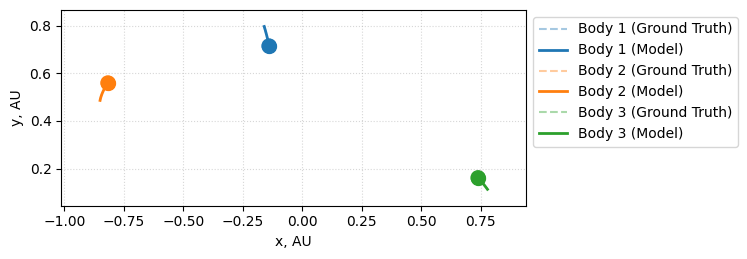

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_trajectory_comparison(N, x_real, y_real, x_ai, y_ai)
plt.savefig(f"{MODELS.get(OPTION_MODEL)}.pdf", bbox_inches="tight")

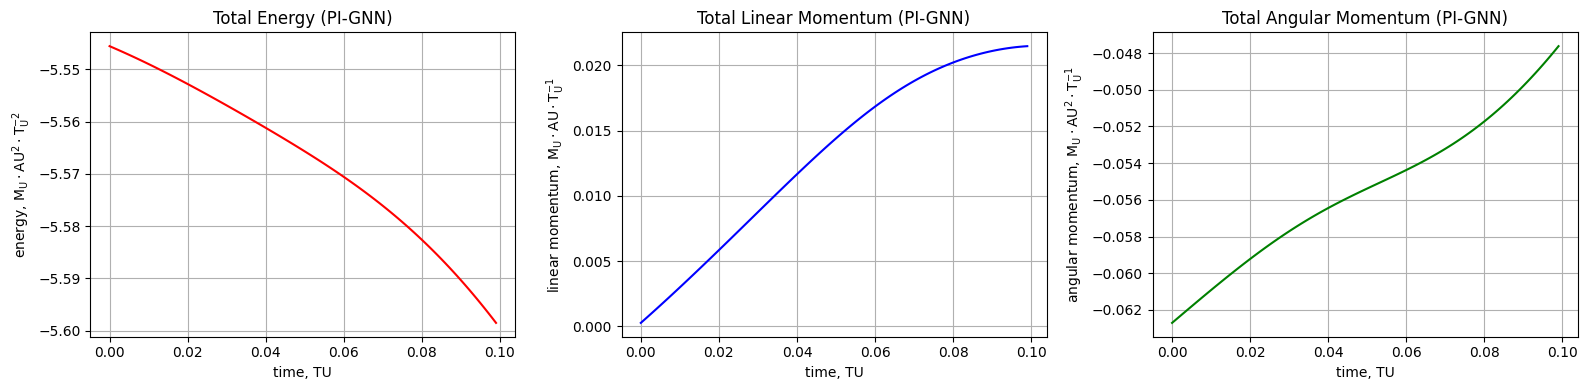

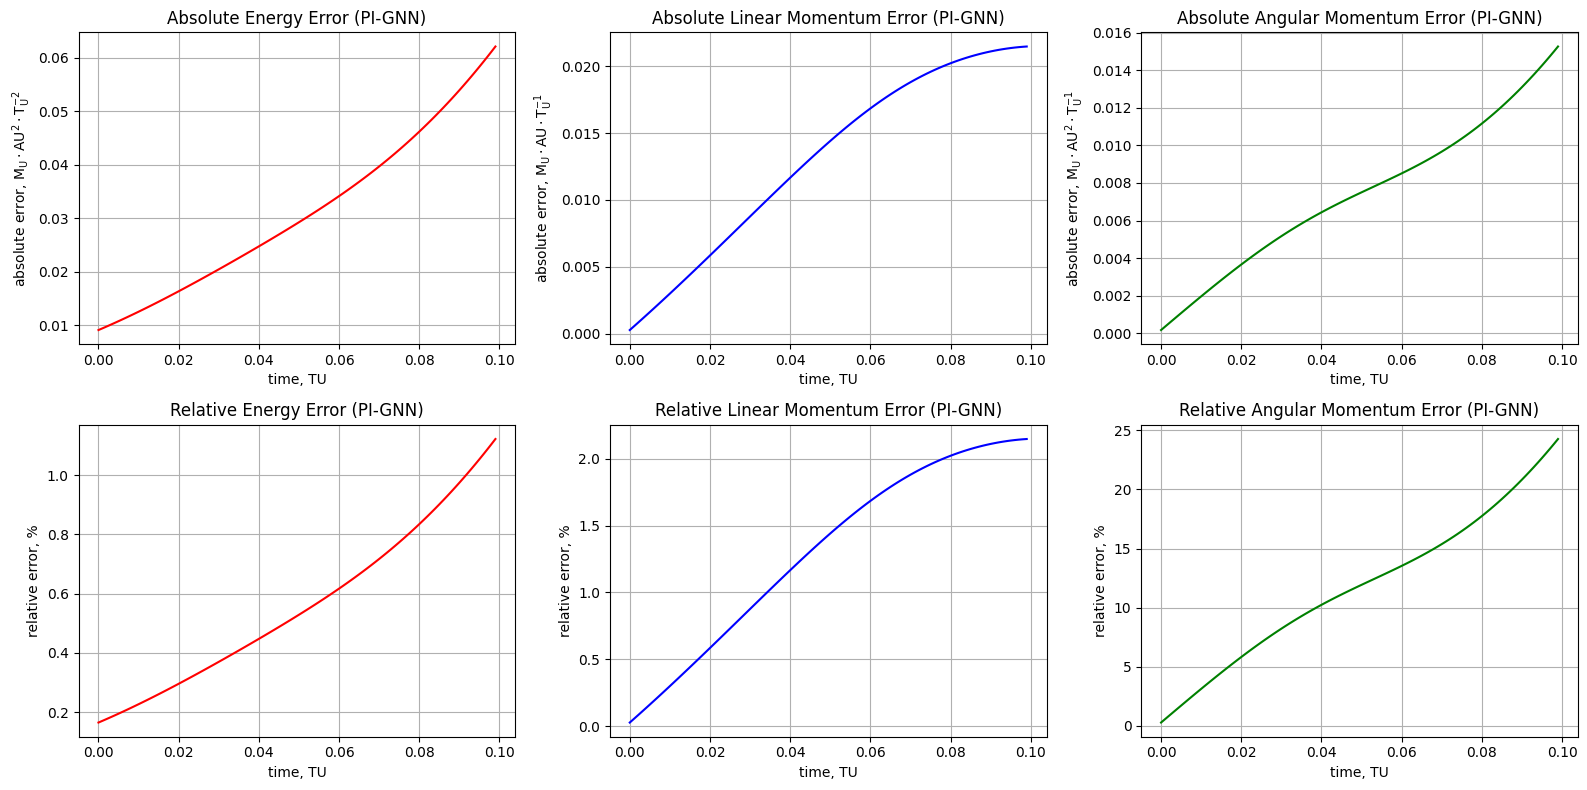

In [ ]:
plot_conserved_quantities(energy_ai, linear_ai, angular_ai, OPTION_MODEL, dt)
plot_errors(abs_energy_ai, abs_linear_ai, abs_angular_ai,
            rel_energy_ai, rel_linear_ai, rel_angular_ai, OPTION_MODEL, dt)